# Phase 1 Probability & Statistics Consolidation

This notebook consolidates the probability and statistics concepts covered in Phase 1 of the AI Engineering Roadmap.

## Goals

By the end, I should be able to explain and use:

- probability rules
- conditional probability and independence
- Bernoulli and Binomial random variables
- expected value
- variance and standard deviation
- Normal distributions and z-scores
- sampling distributions
- standard error
- Law of Large Numbers (LLN)
- Central Limit Theorem (CLT)
- confidence intervals
- hypothesis testing and p-values
- Type I / Type II errors and statistical power
- covariance and correlation


# 1. Probability Rules

## Complement

$$
P(A^c)=1-P(A)
$$

Useful for **"at least one"**:

$$
P(\text{at least one})=1-P(\text{none})
$$

## Union

$$
P(A\cup B)=P(A)+P(B)-P(A\cap B)
$$

"OR" corresponds to union.

## Conditional probability

$$
P(A\mid B)=\frac{P(A\cap B)}{P(B)}
$$

Interpretation: probability of $A$, given that $B$ has occurred.

## Independence

If $A$ and $B$ are independent:

$$
P(A\cap B)=P(A)P(B)
$$

Independence means learning whether one event occurred gives no information about the other.


### Quick practice

1. A classifier has a 6% error rate. What is the probability it is correct?
2. $P(A)=0.30$, $P(B)=0.20$, and $P(A\cap B)=0.08$. Find $P(A\cup B)$.
3. An event has probability 0.10 on each of 5 independent trials. Find the probability it happens at least once.


In [2]:
# Verify after doing by hand
p_correct = 1 - 0.06
p_union = 0.30 + 0.20 - 0.08
p_at_least_one = 1 - (1 - 0.10)**5

print("1.", p_correct)
print("2.", p_union)
print("3.", p_at_least_one)


1. 0.94
2. 0.42
3. 0.40950999999999993


# 2. Bernoulli and Binomial

A **Bernoulli random variable** represents one binary trial.

For example:

$$
X=
\begin{cases}
1 & \text{correct prediction}\\
0 & \text{incorrect prediction}
\end{cases}
$$

We write:

$$
X\sim \mathrm{Bernoulli}(p)
$$

with:

$$
P(X=1)=p, \qquad P(X=0)=1-p
$$

A **Binomial random variable** counts successes across $n$ independent Bernoulli trials:

$$
X\sim \mathrm{Binomial}(n,p)
$$

and:

$$
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}
$$

Examples:

- one prediction correct or wrong → Bernoulli
- number correct out of 100 predictions → Binomial


In [3]:
import numpy as np

rng = np.random.default_rng(42)

# 10,000 repeated experiments:
# each experiment contains 20 independent trials with p = 0.30
samples = rng.binomial(n=20, p=0.30, size=10_000)

print("First 10 Binomial outcomes:", samples[:10])


First 10 Binomial outcomes: [ 8  6  8  7  3 10  7  8  4  6]


# 3. Expected Value, Variance, and Standard Deviation

## Expected value

Expected value is the long-run average value of a random variable.

For a discrete random variable:

$$
E[X]=\sum_x xP(X=x)
$$

For Bernoulli:

$$
E[X]=p
$$

For Binomial:

$$
E[X]=np
$$

## Variance

Variance is the **average squared deviation from the mean**:

$$
\mathrm{Var}(X)=E[(X-E[X])^2]
$$

For Bernoulli:

$$
\mathrm{Var}(X)=p(1-p)
$$

For Binomial:

$$
\mathrm{Var}(X)=np(1-p)
$$

## Standard deviation

$$
SD(X)=\sqrt{\mathrm{Var}(X)}
$$

Standard deviation is the **root-mean-square deviation from the mean**.

Important:

- SD is expressed in the same units as the original data.
- SD is not the range.
- SD alone does not tell me what percentage of observations lie within one SD.
- If all deviations are multiplied by $k$, SD is multiplied by $|k|$ and variance by $k^2$.


In [4]:
n = 20
p = 0.30

print("Empirical mean:", samples.mean())
print("Theoretical mean:", n * p)

print("Empirical variance:", samples.var())
print("Theoretical variance:", n * p * (1 - p))

print("Empirical SD:", samples.std())
print("Theoretical SD:", np.sqrt(n * p * (1 - p)))


Empirical mean: 5.9855
Theoretical mean: 6.0
Empirical variance: 4.19468975
Theoretical variance: 4.199999999999999
Empirical SD: 2.048094175080824
Theoretical SD: 2.0493901531919194


# 4. Normal Distribution and z-Scores

A Normal distribution is written:

$$
X\sim N(\mu,\sigma^2)
$$

where:

- $\mu$ = mean
- $\sigma$ = standard deviation

For a Normal distribution:

- about 68% lies within $\mu\pm1\sigma$
- about 95% lies within $\mu\pm2\sigma$
- about 99.7% lies within $\mu\pm3\sigma$

## z-score

$$
z=\frac{x-\mu}{\sigma}
$$

Interpretation: the number of standard deviations an observation is above or below the mean.

Example:

$$
x=85, \quad \mu=70, \quad \sigma=10
$$

$$
z=\frac{85-70}{10}=1.5
$$

So the observation is 1.5 standard deviations above the mean.


In [5]:
x = 85
mu = 70
sigma = 10

z = (x - mu) / sigma
print("z-score:", z)


z-score: 1.5


# 5. Sampling Distributions and Standard Error

A **sampling distribution** is the distribution of a statistic across hypothetical repeated samples of the same size.

For the sample mean:

$$
E[\bar X]=\mu
$$

So the sampling distribution of the sample mean is centered at the true population mean.

## Standard error

Standard error is the **standard deviation of the sampling distribution**.

For the sample mean (where n = # of observations per sample):

$$
SE(\bar X)=\frac{\sigma}{\sqrt{n}}
$$

Therefore:

$$
n\uparrow \quad \Rightarrow \quad SE\downarrow
$$

Larger samples make sample means cluster more tightly around the population mean.


In [6]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Population with mean 100 and SD 20
population = rng.normal(loc=100, scale=20, size=1_000_000)

def simulated_sample_means(n, repeats=10_000):
    return np.array([
        rng.choice(population, size=n, replace=True).mean()
        for _ in range(repeats)
    ])

means_25 = simulated_sample_means(25)
means_400 = simulated_sample_means(400)

print("n=25 empirical SE:", means_25.std())
print("n=25 theoretical SE:", 20 / np.sqrt(25))

print("n=400 empirical SE:", means_400.std())
print("n=400 theoretical SE:", 20 / np.sqrt(400))


n=25 empirical SE: 3.9528675315162176
n=25 theoretical SE: 4.0
n=400 empirical SE: 1.00757859334122
n=400 theoretical SE: 1.0


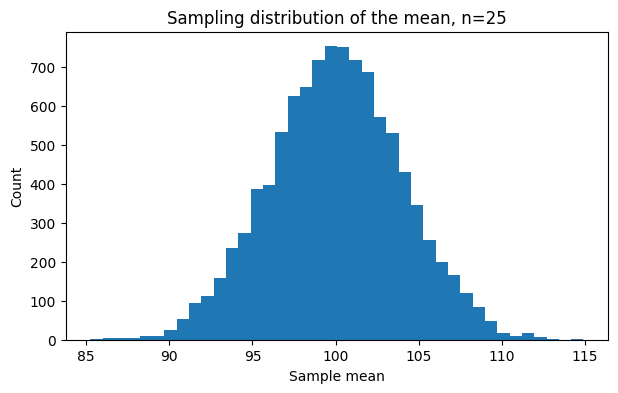

In [7]:
plt.figure(figsize=(7, 4))
plt.hist(means_25, bins=40)
plt.xlabel("Sample mean")
plt.ylabel("Count")
plt.title("Sampling distribution of the mean, n=25")
plt.show()


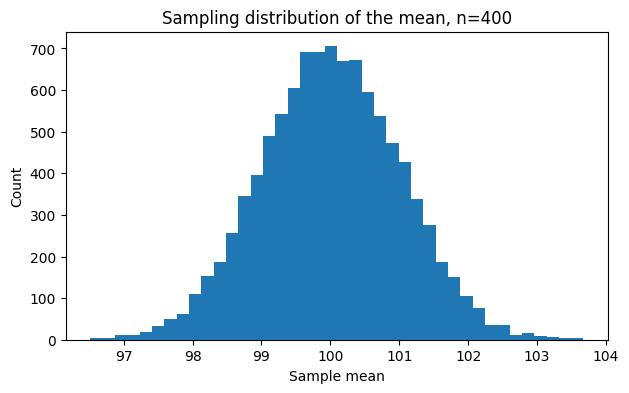

In [8]:
plt.figure(figsize=(7, 4))
plt.hist(means_400, bins=40)
plt.xlabel("Sample mean")
plt.ylabel("Count")
plt.title("Sampling distribution of the mean, n=400")
plt.show()


# 6. LLN vs CLT

## Law of Large Numbers (LLN)

As sample size increases, the sample mean tends toward the true population mean:

$$
\bar X \rightarrow \mu
$$

Think: **Where does the sample mean go?**

Answer: toward $\mu$.

## Central Limit Theorem (CLT)

Under broad conditions, the sampling distribution of the sample mean becomes approximately Normal as sample size becomes sufficiently large.

Think: **What shape does the distribution of sample means take?**

Answer: approximately Normal.

So:

- LLN → where the estimate tends to go
- CLT → shape of the sampling distribution


# 7. Confidence Intervals

General form:

$$
\text{CI}=\text{estimate}\pm(\text{critical value})(SE)
$$

For a mean when population SD is known:

$$
\bar x \pm z^*\frac{\sigma}{\sqrt n}
$$

Common Normal critical values:

| Confidence | Critical value $z^*$ |
|---|---:|
| 90% | 1.645 |
| 95% | 1.960 |
| 99% | 2.576 |

A 95% CI is approximately:

$$
\bar x\pm1.96SE
$$

Interpretation: the interval gives a range of population-parameter values compatible with the observed estimate under this confidence procedure.

Frequentist meaning: if the full sampling-and-interval-building procedure were repeated many times, about 95% of 95% confidence intervals would contain the true parameter. In other words, "in repeated use, about 95% of intervals constructed by the procedure contain the parameter of the population."

Also:

- higher confidence → wider interval
- larger $n$ → smaller SE → narrower interval


In [9]:
x_bar = 104
se = 2
z_star = 1.96

lower = x_bar - z_star * se
upper = x_bar + z_star * se

print("95% CI:", (lower, upper))


95% CI: (100.08, 107.92)


# 8. Hypothesis Testing and p-Values

A hypothesis test begins with:

$$
H_0 = \text{null hypothesis}
$$

and:

$$
H_1 = \text{alternative hypothesis}
$$

Example:

$$
H_0:p=0.75
$$

$$
H_1:p>0.75
$$

## z-style test statistic

$$
z=\frac{\text{observed statistic}-\text{null value}}{SE}
$$

Interpretation: the number of standard errors between the observed statistic and the value predicted by $H_0$.

## p-value

The p-value is the probability, **assuming $H_0$ is true**, of obtaining a result this extreme or more extreme.

E.g.) p = 0.02 means "Assuming null hypothesis is true, there is a 2% probability of observing a result this extreme or more extreme"

Important:

$$
p\text{-value} \neq P(H_0\text{ is true})
$$

Decision rule:

$$
p<\alpha \Rightarrow \text{reject }H_0
$$

$$
p\ge\alpha \Rightarrow \text{fail to reject }H_0
$$

A common threshold is:

$$
\alpha=0.05
$$


In [10]:
from scipy.stats import norm

z = 2

one_sided_p = 1 - norm.cdf(z)
two_sided_p = 2 * (1 - norm.cdf(abs(z)))

print("One-sided p-value:", one_sided_p)
print("Two-sided p-value:", two_sided_p)


One-sided p-value: 0.02275013194817921
Two-sided p-value: 0.04550026389635842


## Accuracy / proportion example

For model accuracy under:

$$
H_0:p=p_0
$$

the null standard error is:

$$
SE=\sqrt{\frac{p_0(1-p_0)}{n}}
$$

Then:

$$
z=\frac{\hat p-p_0}{SE}
$$


In [11]:
p0 = 0.80
p_hat = 0.84
n = 400

se = np.sqrt(p0 * (1 - p0) / n)
z = (p_hat - p0) / se
p_value = 1 - norm.cdf(z)

print("SE:", se)
print("z:", z)
print("one-sided p-value:", p_value)


SE: 0.02
z: 1.9999999999999962
one-sided p-value: 0.02275013194817943


# 9. Type I Error, Type II Error, and Power

## Type I error

Reject $H_0$ even though it is true.

**False positive**

$$
\alpha=P(\text{Type I error})
$$

## Type II error

Fail to reject $H_0$ even though it is false.

**False negative**

$$
\beta=P(\text{Type II error})
$$

## Statistical power

$$
\text{Power}=1-\beta
$$

Statistical power is the probability that a hypothesis test correctly detects a specified real effect when that effect actually exists

E.g) 80% power would mean that under the particular alternative/effect size used in the calculation, repeated effects would successfully reject null hypothesis about 80% of the time

Generally:

$$
n\uparrow \Rightarrow SE\downarrow \Rightarrow \text{Power}\uparrow
$$

A stricter $\alpha$ reduces Type I error risk but can increase Type II error risk.


# 10. Covariance and Correlation

Covariance measures whether two variables tend to vary together.

$$
\mathrm{Cov}(X,Y)=E[(X-\mu_X)(Y-\mu_Y)]
$$

Interpretation:

- positive covariance → tend to move in the same direction
- negative covariance → tend to move in opposite directions
- near-zero covariance → little linear co-movement

Correlation standardizes covariance:

$$
r=\frac{\mathrm{Cov}(X,Y)}{\sigma_X\sigma_Y}
$$

with:

$$
-1\le r\le1
$$

Interpretation:

- $r\approx1$ → strong positive linear relationship
- $r\approx-1$ → strong negative linear relationship
- $r\approx0$ → little or no linear relationship

Important:

- $r=0$ does **not** prove there is no nonlinear relationship.
- correlation does **not** imply causation.


In [12]:
X = np.array([1, 2, 3])
Y = np.array([2, 4, 6])

cov_matrix = np.cov(X, Y, ddof=0)
corr_matrix = np.corrcoef(X, Y)

print("Population covariance:")
print(cov_matrix)

print("\nCorrelation:")
print(corr_matrix)


Population covariance:
[[0.66666667 1.33333333]
 [1.33333333 2.66666667]]

Correlation:
[[1. 1.]
 [1. 1.]]


# 11. Integrated Mini-Lab

In this section we will:

1. simulate a classifier
2. estimate its accuracy
3. calculate a confidence interval
4. test a null hypothesis
5. compare sampling variability at different sample sizes


In [13]:
rng = np.random.default_rng(7)

true_accuracy = 0.84
n = 500

# 1 = correct, 0 = incorrect
predictions = rng.binomial(n=1, p=true_accuracy, size=n)
observed_accuracy = predictions.mean()

print("Observed accuracy:", observed_accuracy)


Observed accuracy: 0.84


In [27]:
# Approximate 95% CI for the observed accuracy
p_hat = observed_accuracy
se_hat = np.sqrt(p_hat * (1 - p_hat) / n)

lower = p_hat - 1.96 * se_hat
upper = p_hat + 1.96 * se_hat

print("Estimated SE:", se_hat)
print("Approx. 95% CI:", (lower, upper))


Estimated SE: 0.009165151389911681
Approx. 95% CI: (np.float64(0.822036303275773), np.float64(0.8579636967242269))


In [15]:
# Hypothesis test:
# H0: true accuracy = 0.80
# H1: true accuracy > 0.80

p0 = 0.80
se_null = np.sqrt(p0 * (1 - p0) / n)

z = (p_hat - p0) / se_null
# norm.cdf(z) gets us the proportion of the standard normal distribution left of z
# Aka 1 - norm.cdf gives us the right-hand tail aka our p value
# right-tail probability = 1 - left-tail probability
p_value = 1 - norm.cdf(z)

print("z statistic:", z)
print("one-sided p-value:", p_value)
# Given p = 0.013 this means if the true accuracy really were 80%, there would be
# about a 1.3% probability of observing an accuracy at least this far above 80%,
# given this sample size. Since p value < 0.05 we reject null hypothesis at 5% significance level

z statistic: 2.236067977499786
one-sided p-value: 0.012673659338734211


In [16]:
# Show how sample size affects sampling variability
# Theoretical SE = what mathematics predicts SE should be
# Empirical SE = what our simulation actually produces
for n in [25, 100, 400, 1600]:
    repeated_accuracies = rng.binomial(n=n, p=true_accuracy, size=10_000) / n
    empirical_se = repeated_accuracies.std()
    theoretical_se = np.sqrt(true_accuracy * (1 - true_accuracy) / n)
    print(
        f"n={n:4d} | empirical SE={empirical_se:.4f} "
        f"| theoretical SE={theoretical_se:.4f}"
    )


n=  25 | empirical SE=0.0737 | theoretical SE=0.0733
n= 100 | empirical SE=0.0365 | theoretical SE=0.0367
n= 400 | empirical SE=0.0184 | theoretical SE=0.0183
n=1600 | empirical SE=0.0092 | theoretical SE=0.0092


# 12. Final Self-Test

Answer these in your own words before looking back at the notes.

1. What is the difference between SD and SE?
2. What does the sampling distribution of the mean contain?
3. Why does increasing $n$ reduce SE?
4. What is the difference between LLN and CLT?
5. What does a 95% CI represent?
6. What does $p=0.02$ mean?
7. Why does $p=0.02$ **not** mean $P(H_0)=0.02$?
8. What is a Type I error?
9. What is a Type II error?
10. What does statistical power mean?
11. What does $r=0$ tell us, and what does it not tell us?
12. Why does correlation not establish causation?


# Phase 1 Summary

The probability/statistics progression in this notebook is:

1. Probability rules
2. Random variables
3. Expected value, variance, and standard deviation
4. Normal distributions and z-scores
5. Sampling distributions and standard error
6. LLN and CLT
7. Confidence intervals
8. Hypothesis testing and p-values
9. Type I / Type II errors and power
10. Covariance and correlation
